# Lab 6 solution: Trajectory Planning

Companion to `TrajectoryPlanningTemplate.ipynb` (`pdfs/Trajectory_Planning.pdf`). **The code cells are the template's own cells with the blanks filled in**
(changes beyond the blanks are commented in the cell). After each code cell:
- **Concept**: what the task computes and why;
- **How it works**: the code line by line, every new piece of syntax with a tiny example;
- sometimes an **Example**: a short check, shown as code + its real output (text only, nothing extra to run).

**Real robot by default.** Tasks 1–18 are offline (no robot needed). Task 19 streams the planned trajectory to the real controller `mycobot_control` and **moves the arm**.
- ⚠ Run this notebook **cell by cell**, never "Run All". Cells that move the arm are marked **[MOVES]**: workspace clear,
  hand at the robot's power switch, first move small and slow.
- Cells that need the robot have **no saved output** here (they were not run on the laptop); all other outputs are real.

**Simulation (optional).** Blocks marked 🧪 show how to run the same cells **without** the robot, against
`solutions/sim_robot.py` (a simulated arm behind a virtual serial port). They come after the real-robot solution and
are never needed in the lab.

**Run from `solutions/`.** `import labpaths` (added to the setup cell) puts the repo root on `sys.path`, so
`helperFunctions.py` imports as in the template, and finds the course URDF `mycobot_280_gazebo.urdf` in the repo root.

**The idea of the lab.** A **path** is a set of poses; a **trajectory** adds *time*: $q(t)$, $\dot q(t)$, $\ddot q(t)$.
The trapezoidal profile is the time-optimal law under a velocity limit $v_{max}$ and an acceleration limit $a_{max}$:
accelerate at $a_{max}$, cruise at $v_{max}$, decelerate at $a_{max}$. If the move is too short to reach $v_{max}$ the
cruise disappears and the profile is **triangular**.

# Trajectory Planning for the myCobot 280 Labs
## Lab 6: Trapezoidal Velocity Profiles and Minimum-Time Joint Motion

Run this notebook from `~/venvs/mycobot`:

```bash
source ~/venvs/mycobot/bin/activate
jupyter lab
```

This lab continues Labs 1–5. You will construct smooth point-to-point joint-space trajectories for the myCobot 280 under velocity and acceleration limits. The focus is trapezoidal velocity profiles, the triangular short-move case, minimum-time motion, and practical trajectory sampling for the robot workflow.

All offline calculations in this notebook should be expressed in radians, rad/s, and rad/s² unless a task explicitly starts from the worked example in degrees.

In [1]:
%matplotlib widget
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3

np.set_printoptions(precision=6, suppress=True)    # suppress=True added: no 1e-17 noise in printed arrays

**How it works**: `import time` is needed for the timed publishing in Task 19 (`time.sleep`, `time.time`).

## Setup

### 1. Import the myCobot 280 URDF model

Load the URDF model distributed alongside this notebook. We use it here mainly to inspect the six-joint structure and to keep the trajectory-planning lab connected to the same myCobot 280 model used in the previous labs.

In [2]:
notebook_path = os.getcwd()
mycobot_urdf_path = os.path.join(notebook_path, 'mycobot_280_gazebo.urdf')
if not os.path.exists(mycobot_urdf_path):        # added: the notebook runs in solutions/, the URDF is in the repo root
    import labpaths
    mycobot_urdf_path = labpaths.urdf_path()
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

Using course URDF: /home/mano-ub22/TUD/cobots/mycobot_280_gazebo.urdf
ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         │       │ world  │ SE3()                                               │
│    2 │ joint1         │       │ g_base │ SE3()                                               │
│    3 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    4 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    5 │ joint4         │     2 │ joint3 │ SE3(-0.1104, 0, 0) ⊕ Rz(q2)       

/tmp/ipykernel_65978/107154348.py:6: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


**How it works** (as in Labs 3–5): `Robot.URDF(path)` builds the model. Here it is only needed for the number of joints
and their limits; the planning itself is per joint.

### 2. Inspect the joint-space dimension and limits

Inspect the number of joints and the available joint limits. These limits are not the same as trajectory velocity/acceleration limits, but they are useful when selecting start and goal configurations for trajectory generation.

In [3]:
print('Number of joints:', mycobot.n)
print('Joint limits (if available):')
print(mycobot.qlim)

Number of joints: 6
Joint limits (if available):
[[-2.9322  -2.3562  -2.618   -2.5307  -2.8798  -3.14159]
 [ 2.9322   2.3562   2.618    2.5307   2.8798   3.14159]]


**Concept.** *Position* limits (`qlim`) say which start and goal poses are allowed. They are different from the
*velocity* and *acceleration* limits that shape the trajectory (Task 9).

**How it works**: `mycobot.qlim` is 2×6: row 0 = lower, row 1 = upper limit, in radians (±2.93 rad = ±168° for joint 1).

## Scalar Trapezoidal Profile Fundamentals

For a scalar point-to-point move from $q_0$ to $q_f$, the displacement is:

$$\Delta q = q_f - q_0$$

A full trapezoidal profile has:
- **Acceleration phase:** velocity increases linearly from zero to $v_{\max}$, position is quadratic.
- **Constant-velocity cruise phase:** velocity remains at $v_{\max}$, position changes linearly.
- **Deceleration phase:** velocity decreases linearly back to zero, position is quadratic.

If the move is too short to reach $v_{\max}$, the cruise phase disappears and the profile becomes **triangular**.

**Trapezoidal case** ($|\Delta q| > v_{\max}^2 / a_{\max}$):

$$t_a = \frac{v_{\max}}{a_{\max}}, \quad t_c = \frac{|\Delta q| - v_{\max}^2/a_{\max}}{v_{\max}}, \quad t_f = 2t_a + t_c$$

**Triangular case** ($|\Delta q| \leq v_{\max}^2 / a_{\max}$):

$$t_a = \sqrt{\frac{|\Delta q|}{a_{\max}}}, \quad v_{\text{peak}} = a_{\max} \cdot t_a, \quad t_f = 2t_a$$

### 3. Reproduce the worked example from the lab PDF

Use the example:
- $q_0 = 0°$, $q_f = 90°$
- $v_{\max} = 45°/\text{s}$, $a_{\max} = 90°/\text{s}^2$

Expected result: $t_a = 0.5$ s, $t_c = 1.5$ s, $t_f = 2.5$ s (trapezoidal).

In [4]:
q0_deg = 0.0
qf_deg = 90.0
vmax_deg = 45.0
amax_deg = 90.0

dq_deg = qf_deg - q0_deg
dq_abs_deg = abs(dq_deg)

ta = vmax_deg / amax_deg  # acceleration time: v = a t reaches vmax after vmax / amax
dq_accdec = vmax_deg**2 / amax_deg  # distance covered while accelerating AND decelerating

is_trapezoidal = dq_abs_deg > dq_accdec  # can the move reach the velocity limit?

if is_trapezoidal:
    tc = (dq_abs_deg - dq_accdec) / vmax_deg  # cruise: the remaining distance at vmax
    tf = 2 * ta + tc  # total move duration
else:
    tc = 0.0
    tf = 2 * np.sqrt(dq_abs_deg / amax_deg)
    vpeak = amax_deg * np.sqrt(dq_abs_deg / amax_deg)

print('dq (deg):', dq_deg)
print('ta (s):', ta)
print('dq_accdec (deg):', dq_accdec)
print('trapezoidal:', is_trapezoidal)
print('tc (s):', tc)
print('tf (s):', tf)

dq (deg): 90.0
ta (s): 0.5
dq_accdec (deg): 22.5
trapezoidal: True
tc (s): 1.5
tf (s): 2.5


**Concept, step by step** (the PDF's worked example)
- $t_a = v_{max}/a_{max}$ = 45/90 = 0.5 s: with constant acceleration $v = a\,t$.
- One ramp covers $\tfrac12 a t_a^2 = \tfrac12 v_{max}^2/a_{max}$; acceleration **and** deceleration together cover
  $v_{max}^2/a_{max}$ = 45²/90 = **22.5°**.
- 90° > 22.5°, so there is room to cruise: the remaining 67.5° at 45°/s take $t_c$ = 1.5 s. Total $t_f = 2t_a + t_c$ = 2.5 s.

**How it works**
- `is_trapezoidal = a > b` stores a **boolean** (`True`/`False`); the `if/else` picks one of the two formulas, because the
  physics has two cases.
- `abs(x)` is Python's absolute value; `x**2` is the square.

**Example: area under the velocity curve = distance**

```python
t_chk = np.linspace(0, tf, 100001)
v_chk = np.where(t_chk <= ta, amax_deg * t_chk,
                 np.where(t_chk <= ta + tc, vmax_deg, vmax_deg - amax_deg * (t_chk - ta - tc)))
integrate = getattr(np, 'trapezoid', None) or np.trapz       # np.trapz was renamed in NumPy 2
print('area under the trapezoid (deg):', integrate(v_chk, t_chk))
```

Output:
```text
area under the trapezoid (deg): 90.00000000000001
```

`np.where(cond, a, b)` picks `a` where `cond` is true, else `b`, element-wise (nested: three branches).
`np.trapz(y, x)` integrates numerically. `getattr(obj, name, None) or fallback` uses the new name if it exists.

### 4. Convert the worked example to SI units

Convert the same worked example from degrees to radians, rad/s, and rad/s². Verify that the timing results (`ta`, `tc`, `tf`) are unchanged — they depend on ratios, not on the unit system.

In [5]:
q0 = np.radians(q0_deg)  # Convert the start angle to radians
qf = np.radians(qf_deg)  # Convert the goal angle to radians
vmax = np.radians(vmax_deg)  # Convert the velocity limit to radians per second
amax = np.radians(amax_deg)  # Convert the acceleration limit to radians per second squared

print('q0 (rad):', q0)
print('qf (rad):', qf)
print('vmax (rad/s):', vmax)
print('amax (rad/s^2):', amax)

q0 (rad): 0.0
qf (rad): 1.5707963267948966
vmax (rad/s): 0.7853981633974483
amax (rad/s^2): 1.5707963267948966


**Why the times do not change:** they depend on **ratios**. $v_{max}/a_{max}$ is "seconds" in °/s ÷ °/s² and in
rad/s ÷ rad/s²; the conversion factor π/180 cancels. Rule for the lab: pick one unit system and stay in it (the controller
uses radians on its topics).

**Example: the timing in SI units**

```python
ta_si = vmax / amax
tc_si = (abs(qf - q0) - vmax**2 / amax) / vmax
print('ta, tc, tf (s):', ta_si, tc_si, 2 * ta_si + tc_si)
```

Output:
```text
ta, tc, tf (s): 0.5 1.5 2.5
```

### 5. Build the scalar profile timing logic

Implement the timing logic that decides between the trapezoidal and triangular case for a general scalar move. Handle both positive and negative displacements via a `direction` sign.

In [6]:
def scalar_profile_timing(q0, qf, vmax, amax):
    dq = qf - q0
    dq_abs = abs(dq)
    direction = np.sign(dq)  # +1 or -1 (0 if there is no motion)

    ta_nom = vmax / amax  # nominal acceleration time (if vmax is reached)
    dq_accdec = vmax**2 / amax  # displacement needed to accelerate to vmax and stop again

    if dq_abs > dq_accdec:
        # trapezoidal
        ta = ta_nom
        tc = (dq_abs - dq_accdec) / vmax
        tf = 2 * ta + tc
        vpeak = vmax
        profile_type = 'trapezoidal'
    else:
        # triangular
        ta = np.sqrt(dq_abs / amax)  # accelerate for the first half, decelerate for the second
        tc = 0.0
        tf = 2 * ta  # total duration of the triangular profile
        vpeak = amax * ta  # peak velocity, reached at the turning point
        profile_type = 'triangular'

    return {
        'dq': dq,
        'dq_abs': dq_abs,
        'direction': direction,
        'ta': ta,
        'tc': tc,
        'tf': tf,
        'vpeak': vpeak,
        'profile_type': profile_type,
    }

timing = scalar_profile_timing(q0, qf, vmax, amax)
timing

{'dq': 1.5707963267948966,
 'dq_abs': 1.5707963267948966,
 'direction': 1.0,
 'ta': 0.5,
 'tc': 1.5,
 'tf': 2.5,
 'vpeak': 0.7853981633974483,
 'profile_type': 'trapezoidal'}

**Concept.** The same logic for any move. **Triangular case:** no cruise, so the move is two ramps of length
$t_a$: distance $2\cdot\tfrac12 a_{max}t_a^2 = |\Delta q|$ ⇒ $t_a = \sqrt{|\Delta q|/a_{max}}$, and the turning-point speed
$v_{peak} = a_{max}t_a < v_{max}$. All durations use $|\Delta q|$; the direction is applied when sampling (Task 6).

**How it works**
- `np.sign(dq)` gives +1, −1 or 0.
- Returning a **dictionary** bundles eight results under names: `timing['tf']` instead of remembering positions in a tuple.

**Example: one function, many move lengths (45 deg/s, 90 deg/s^2)**

```python
for d_deg in (5, 10, 22.5, 30, 90, -90):
    r = scalar_profile_timing(0.0, np.radians(d_deg), np.radians(45), np.radians(90))
    print(f"{d_deg:6.1f} deg  {r['profile_type']:11s}  ta {r['ta']:.3f}  tc {r['tc']:.3f}  tf {r['tf']:.3f} s  "
          f"vpeak {np.degrees(r['vpeak']):5.1f} deg/s")
```

Output:
```text
   5.0 deg  triangular   ta 0.236  tc 0.000  tf 0.471 s  vpeak  21.2 deg/s
  10.0 deg  triangular   ta 0.333  tc 0.000  tf 0.667 s  vpeak  30.0 deg/s
  22.5 deg  triangular   ta 0.500  tc 0.000  tf 1.000 s  vpeak  45.0 deg/s
  30.0 deg  trapezoidal  ta 0.500  tc 0.167  tf 1.167 s  vpeak  45.0 deg/s
  90.0 deg  trapezoidal  ta 0.500  tc 1.500  tf 2.500 s  vpeak  45.0 deg/s
 -90.0 deg  trapezoidal  ta 0.500  tc 1.500  tf 2.500 s  vpeak  45.0 deg/s
```

Below 22.5° the profile is triangular and the peak stays below 45°/s; 22.5° is the borderline; −90° takes as long as +90°.

### 6. Sample the scalar position, velocity, and acceleration profile

Create a sampled scalar trajectory over time for the move above. Use the acceleration, cruise, and deceleration phase definitions explicitly.

During each phase:
- **Acceleration** ($0 \leq t \leq t_a$): $\ddot{q} = \text{dir} \cdot a_{\max}$, $\dot{q} = \text{dir} \cdot a_{\max} \cdot t$, $q = q_0 + \frac{1}{2} \text{dir} \cdot a_{\max} \cdot t^2$
- **Cruise** ($t_a < t \leq t_a + t_c$): $\ddot{q} = 0$, $\dot{q} = \text{dir} \cdot v_{\text{peak}}$, position evolves linearly
- **Deceleration** ($t_a + t_c < t \leq t_f$): $\ddot{q} = -\text{dir} \cdot a_{\max}$, velocity ramps back to zero

In [7]:
def sample_scalar_profile(q0, qf, vmax, amax, dt):
    timing = scalar_profile_timing(q0, qf, vmax, amax)

    ta = timing['ta']
    tc = timing['tc']
    tf = timing['tf']
    direction = timing['direction']
    vpeak = timing['vpeak']

    t = np.arange(0.0, tf + dt, dt)

    q = np.zeros_like(t)
    qd = np.zeros_like(t)
    qdd = np.zeros_like(t)

    for i, ti in enumerate(t):
        if ti > tf:
            # added: np.arange can put the last sample just after tf; hold the goal there (else the decel overshoots)
            qdd[i], qd[i], q[i] = 0.0, 0.0, qf
        elif ti <= ta:
            # acceleration phase
            qdd[i] = direction * amax
            qd[i] = direction * amax * ti
            q[i] = q0 + 0.5 * direction * amax * ti**2
        elif ti <= ta + tc:
            # cruise phase
            qdd[i] = 0.0
            qd[i] = direction * vpeak
            q[i] = q0 + direction * (0.5 * amax * ta**2 + vpeak * (ti - ta))  # position at end of accel + cruise distance
        else:
            # deceleration phase
            td = ti - ta - tc  # time within decel phase
            qdd[i] = -direction * amax
            qd[i] = direction * (vpeak - amax * td)
            q[i] = q0 + direction * (0.5 * amax * ta**2 + vpeak * tc + vpeak * td - 0.5 * amax * td**2)

    return t, q, qd, qdd, timing

t, q, qd, qdd, timing = sample_scalar_profile(q0, qf, vmax, amax, dt=0.01)
print(timing)

{'dq': 1.5707963267948966, 'dq_abs': 1.5707963267948966, 'direction': 1.0, 'ta': 0.5, 'tc': 1.5, 'tf': 2.5, 'vpeak': 0.7853981633974483, 'profile_type': 'trapezoidal'}


**Concept.** Each phase has its own formulas ($dir$ = sign of the move, $t_d = t - t_a - t_c$):

| phase | $\ddot q$ | $\dot q$ | $q$ |
|---|---|---|---|
| accelerate, $t \le t_a$ | $dir\,a_{max}$ | $dir\,a_{max}t$ | $q_0 + \tfrac12 dir\,a_{max}t^2$ |
| cruise, $t \le t_a + t_c$ | 0 | $dir\,v_{peak}$ | $q_0 + dir(\tfrac12 a_{max}t_a^2 + v_{peak}(t - t_a))$ |
| decelerate | $-dir\,a_{max}$ | $dir(v_{peak} - a_{max}t_d)$ | $q_0 + dir(\tfrac12 a_{max}t_a^2 + v_{peak}t_c + v_{peak}t_d - \tfrac12 a_{max}t_d^2)$ |

The cruise position = ramp distance + constant-speed distance; the deceleration position = ramp + cruise + the mirror image
of a ramp.

**How it works**
- `np.arange(0.0, tf + dt, dt)`: time samples; `np.zeros_like(t)`: three result arrays of the same length.
- `for i, ti in enumerate(t):` index and time together; `if / elif / else` picks the phase.
- **The trap (added branch):** `np.arange` steps in floating point, so the last sample is often slightly **after** $t_f$.
  The deceleration formula would keep decelerating there: negative velocity, position past the goal. The first branch
  holds the goal. `a, b, c = 0.0, 0.0, qf` assigns three values at once.

**Example: the phases join without jumps**

```python
print('q(end) - qf =', q[-1] - qf, '   qd(end) =', qd[-1])
print('largest position step (rad):', np.max(np.abs(np.diff(q))), ' ~ vmax*dt =', vmax * 0.01)
print('largest velocity step (rad/s):', np.max(np.abs(np.diff(qd))), ' ~ amax*dt =', amax * 0.01)
```

Output:
```text
q(end) - qf = 0.0    qd(end) = 0.0
largest position step (rad): 0.00785398163397466  ~ vmax*dt = 0.007853981633974483
largest velocity step (rad/s): 0.015707963267949432  ~ amax*dt = 0.015707963267948967
```

`np.diff(a)` = `a[i+1] - a[i]`. No step is larger than one time step's worth of motion: position and velocity are continuous.

### 7. Plot the scalar trajectory

Plot position, velocity, and acceleration for the sampled scalar profile.

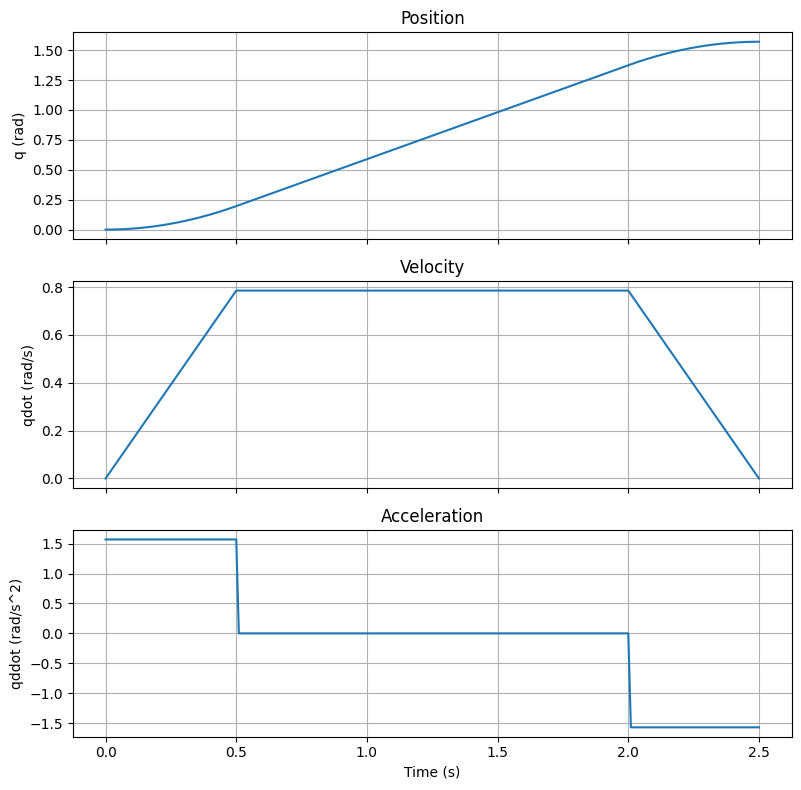

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t, q)
axes[0].set_ylabel('q (rad)')
axes[0].set_title('Position')
axes[0].grid(True)

axes[1].plot(t, qd)
axes[1].set_ylabel('qdot (rad/s)')
axes[1].set_title('Velocity')
axes[1].grid(True)

axes[2].plot(t, qdd)
axes[2].set_ylabel('qddot (rad/s^2)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Acceleration')
axes[2].grid(True)

plt.tight_layout()

**Reading the plots** (PDF question 4). Acceleration: three steps $+a_{max}$, 0, $-a_{max}$. Velocity: ramp, plateau,
ramp = the trapezoid. Position: parabola, straight line, parabola = an S-curve with flat start and end. Each curve is the
integral of the one below. The acceleration **jumps**, so a trapezoidal profile is not jerk-limited (question 3b).

**How it works**: `plt.subplots(3, 1, sharex=True)`: three stacked plots sharing the time axis.

## Joint-Space Trajectory Planning for the myCobot 280

### 8. Define a start and goal configuration

Choose a safe point-to-point move in joint space for the myCobot 280. Keep the motion moderate and away from obvious joint-limit extremes.

In [9]:
q_start = np.array([0.0, -np.pi/4, -np.pi/4, 0.0, np.pi/6, 0.0], dtype=float)
q_goal = np.array([np.pi/3, 0.0, -np.pi/2, np.pi/6, np.pi/3, -np.pi/4], dtype=float)

dq = q_goal - q_start
print('q_start:', q_start)
print('q_goal :', q_goal)
print('dq     :', dq)

q_start: [ 0.       -0.785398 -0.785398  0.        0.523599  0.      ]
q_goal : [ 1.047198  0.       -1.570796  0.523599  1.047198 -0.785398]
dq     : [ 1.047198  0.785398 -0.785398  0.523599  0.523599 -0.785398]


**Concept.** A moderate move: in degrees `dq` = [60, 45, −45, 30, 30, −45]. ⚠ For Task 19 on the robot, the start must be
**where the arm is**: there you set `q_start` to the measured pose and `q_goal = q_start + small offsets` (Task 19 shows how).

**How it works**: `q_goal - q_start` subtracts joint by joint; `dtype=float` makes sure the array holds floats.

**Example: both poses inside the joint limits?**

```python
inside = lambda q: bool(np.all((q >= mycobot.qlim[0]) & (q <= mycobot.qlim[1])))
print('start inside:', inside(q_start), '  goal inside:', inside(q_goal))
```

Output:
```text
start inside: True   goal inside: True
```

`lambda q: ...` is a small anonymous function; `&` is element-wise "and".

### 9. Define velocity and acceleration limits

The myCobot 280 codebase uses a single velocity limit for all joints: `max_joint_speed_deg_s = 150.0` (~2.618 rad/s), and a single acceleration limit: `accel_limit_rad_s2 = 1.0` rad/s². Use these codebase defaults as the planning limits.

In [10]:
# Codebase defaults from mycobot_control.py
vmax_all = np.radians(150.0)  # ~2.618 rad/s
amax_all = 1.0                # rad/s^2

print(f'vmax: {vmax_all:.4f} rad/s ({np.degrees(vmax_all):.1f} deg/s)')
print(f'amax: {amax_all:.4f} rad/s^2')

vmax: 2.6180 rad/s (150.0 deg/s)
amax: 1.0000 rad/s^2


**Key observation.** $v_{max}^2/a_{max} = 2.618^2/1 = 6.85$ rad ≈ **393°**. A joint must travel more than that to ever
cruise, but no myCobot joint can move 393°. So **with the controller's limits every joint move is triangular**: the joint
never reaches 150°/s, and the **acceleration limit decides the motion time**, $t_f = 2\sqrt{|\Delta q|/a_{max}}$ (four
times the distance = twice the time). That is why the PDF's worked example uses other numbers.

### 10. Compute the minimum motion time for each joint

For each joint, compute the minimum point-to-point motion time under the shared `vmax` and `amax`. Then identify the slowest joint, which determines the synchronized total motion time for the full multi-joint move.

In [11]:
joint_timings = []

for j in range(mycobot.n):
    tj = scalar_profile_timing(q_start[j], q_goal[j], vmax_all, amax_all)
    joint_timings.append(tj)

tf_joint = np.array([tj['tf'] for tj in joint_timings])
tf_sync = np.max(tf_joint)  # the slowest joint sets the synchronized duration

print('Per-joint minimum times:', tf_joint)
print('Synchronized total time:', tf_sync)
print('Time-limiting joint index:', np.argmax(tf_joint))  # index of the joint that needs the longest time (0 = joint 1)

Per-joint minimum times: [2.046653 1.772454 1.772454 1.447203 1.447203 1.772454]
Synchronized total time: 2.046653415892977
Time-limiting joint index: 0


**Concept.** All joints must start and stop **together** (otherwise the tool moves along an unpredictable curve), so the
whole move takes as long as the slowest joint: here joint 1 (index 0, the 60° move).

**How it works**
- `[tj['tf'] for tj in joint_timings]`: a list comprehension collects `tf` from each dictionary.
- `np.max(a)` = the largest value, `np.argmax(a)` = its **index** (0-based).

### 11. How the myCobot 280 controller synchronizes joint motion

The codebase's `_build_ee_profile()` uses a different synchronization approach than the per-joint method above. Instead of computing independent per-joint profiles and stretching them to a common time, it:

1. Finds the joint with the **largest displacement** (`max_delta`).
2. Builds a single trapezoidal/triangular velocity profile for that joint.
3. Scales all other joints proportionally: `v_cmd[i] = v_max * (delta[i] / max_delta)`.

This ensures all joints start and finish simultaneously with a single unified profile shape. The practical effect is the same — smooth coordinated motion — but the implementation is simpler because only one profile needs to be computed.

Additionally, the codebase enforces a minimum total time of `ee_min_time_s = 0.5` s. If the computed profile is shorter, the time is clamped and the velocity is reduced accordingly.

### 12. Build synchronized profiles using the codebase approach

Following the `_build_ee_profile()` method from the codebase: identify the joint with the largest displacement, build a single trapezoidal/triangular profile for that joint, then scale all other joints proportionally so they start and finish together.

In [12]:
dt = 0.02

# Find the joint with the largest displacement (codebase: max_delta)
dq_abs = np.abs(dq)
dominant_joint = np.argmax(dq_abs)
max_delta = dq_abs[dominant_joint]

print(f'Dominant joint: {dominant_joint} (|dq| = {max_delta:.4f} rad)')

# Build the profile for the dominant joint
timing_dom = scalar_profile_timing(q_start[dominant_joint], q_goal[dominant_joint], vmax_all, amax_all)
tf_sync = timing_dom['tf']
print(f'Synchronized total time: {tf_sync:.4f} s ({timing_dom["profile_type"]})')

t_sync = np.arange(0.0, tf_sync + dt, dt)

q_traj = np.zeros((len(t_sync), mycobot.n))
qd_traj = np.zeros((len(t_sync), mycobot.n))
qdd_traj = np.zeros((len(t_sync), mycobot.n))

# Sample the dominant joint's profile
t_dom, q_dom, qd_dom, qdd_dom, _ = sample_scalar_profile(
    q_start[dominant_joint], q_goal[dominant_joint], vmax_all, amax_all, dt
)

# For each joint, scale its motion proportionally to the dominant joint
for j in range(mycobot.n):
    if max_delta < 1e-12:
        q_traj[:, j] = q_start[j]
        continue

    ratio = dq[j] / dq[dominant_joint]  # signed displacement ratio relative to the dominant joint
    n_pts = min(len(t_sync), len(t_dom))

    for k in range(n_pts):
        q_traj[k, j] = q_start[j] + ratio * (q_dom[k] - q_start[dominant_joint])  # synchronized position
        qd_traj[k, j] = ratio * qd_dom[k]  # synchronized velocity
        qdd_traj[k, j] = ratio * qdd_dom[k]  # synchronized acceleration

    # Fill remaining points if t_sync is longer than t_dom
    if n_pts < len(t_sync):
        q_traj[n_pts:, j] = q_goal[j]

Dominant joint: 0 (|dq| = 1.0472 rad)
Synchronized total time: 2.0467 s (triangular)


**Concept.** The controller's way (Task 11): one profile for the joint with the largest move, every other joint scaled by
$r_j = \Delta q_j/\Delta q_{dom}$: $q_j(t) = q_{start,j} + r_j\,(q_{dom}(t) - q_{start,dom})$. Scaling multiplies position change,
velocity **and** acceleration by $r_j$, and $|r_j| \le 1$, so no joint exceeds limits the dominant joint satisfies.

**How it works**
- `np.argmax(dq_abs)`: index of the largest $|\Delta q|$.
- `ratio` is **signed**: joints moving the other way (3 and 6 here) need no extra code; the dominant joint gets exactly 1.
- `q_traj[k, j]`: row = time sample, column = joint.
- `min(len(t_sync), len(t_dom))` protects against the two `arange` calls giving different lengths; `continue` skips to the
  next loop iteration.

**Example: the same without the inner loop (vectorised)**

```python
n = min(len(t_sync), len(t_dom))
q_vec = np.zeros_like(q_traj)
for j in range(mycobot.n):
    q_vec[:n, j] = q_start[j] + (dq[j] / dq[dominant_joint]) * (q_dom[:n] - q_start[dominant_joint])
print('ratios:', dq / dq[dominant_joint], '  identical:', np.allclose(q_vec[:n], q_traj[:n]))
```

Output:
```text
ratios: [ 1.    0.75 -0.75  0.5   0.5  -0.75]   identical: True
```

NumPy applies the formula to the whole column `[:n, j]` at once: shorter and much faster than the `k` loop.

### 13. Check the trajectory endpoints and continuity

Verify that:
- the first configuration equals `q_start`
- the last configuration equals `q_goal`
- the start and end velocities are approximately zero

In [13]:
print('q(0):', q_traj[0, :])
print('q(tf):', q_traj[-1, :])
print('qdot(0):', qd_traj[0, :])
print('qdot(tf):', qd_traj[-1, :])

q(0): [ 0.       -0.785398 -0.785398  0.        0.523599  0.      ]
q(tf): [ 1.047198  0.       -1.570796  0.523599  1.047198 -0.785398]
qdot(0): [ 0.  0. -0.  0.  0. -0.]
qdot(tf): [ 0.  0. -0.  0.  0. -0.]


**Check.** First row = `q_start`, last row = `q_goal`, start and end velocities 0: the arm starts and stops smoothly,
unlike a single jump command. (`q_traj[-1, :]` = last row.)

### 14. Plot the multi-joint trajectory

Plot joint position, velocity, and acceleration for all six joints.

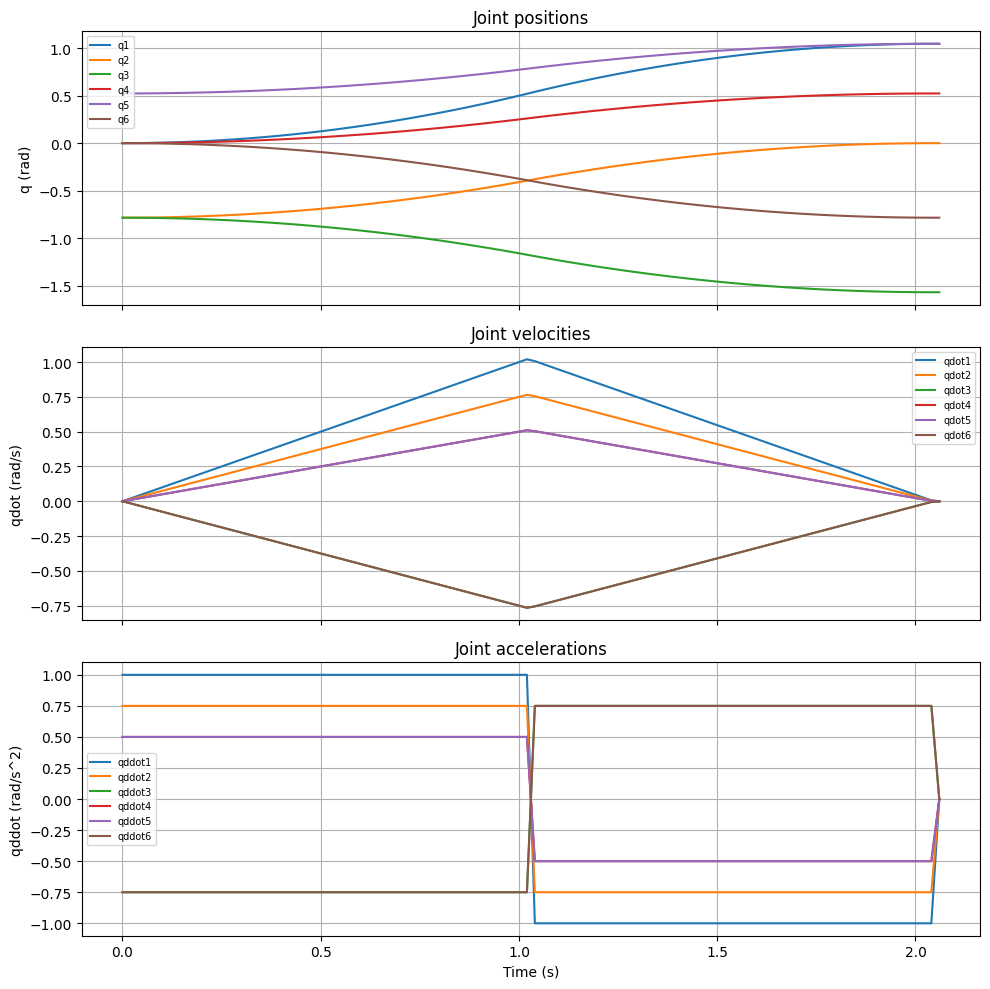

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for j in range(mycobot.n):
    axes[0].plot(t_sync, q_traj[:, j], label=f'q{j+1}')
    axes[1].plot(t_sync, qd_traj[:, j], label=f'qdot{j+1}')
    axes[2].plot(t_sync, qdd_traj[:, j], label=f'qddot{j+1}')

axes[0].set_ylabel('q (rad)')
axes[0].set_title('Joint positions')
axes[0].grid(True)
axes[0].legend(fontsize=7)

axes[1].set_ylabel('qdot (rad/s)')
axes[1].set_title('Joint velocities')
axes[1].grid(True)
axes[1].legend(fontsize=7)

axes[2].set_ylabel('qddot (rad/s^2)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Joint accelerations')
axes[2].grid(True)
axes[2].legend(fontsize=7)

plt.tight_layout()

**What you see.** Six curves of the **same shape**, scaled by the ratios (negative for joints 3 and 6): they start, peak
and stop together. The velocities are triangles (no cruise, Task 9); the accelerations two rectangles.

### 15. Check constraint satisfaction

Verify numerically that the generated joint velocity and acceleration profiles do not exceed the specified limits.

In [15]:
qd_peak = np.max(np.abs(qd_traj), axis=0)
qdd_peak = np.max(np.abs(qdd_traj), axis=0)

print('Peak |qdot|:', qd_peak)
print('Velocity limit:', vmax_all)
print('Velocity within limits:', bool(np.all(qd_peak <= vmax_all + 1e-9)))  # every joint's peak <= the limit

print('Peak |qddot|:', qdd_peak)
print('Acceleration limit:', amax_all)
print('Acceleration within limits:', bool(np.all(qdd_peak <= amax_all + 1e-9)))  # every joint's peak <= the limit

Peak |qdot|: [1.02  0.765 0.765 0.51  0.51  0.765]
Velocity limit: 2.6179938779914944
Velocity within limits: True
Peak |qddot|: [1.   0.75 0.75 0.5  0.5  0.75]
Acceleration limit: 1.0
Acceleration within limits: True


**How it works**
- `np.max(np.abs(a), axis=0)`: the largest absolute value of each **column** = one peak per joint.
- `+ 1e-9`: a tolerance, because the dominant joint reaches the acceleration limit *exactly* and rounding could make it
  fail. `bool(...)` turns NumPy's `numpy.bool_` into plain `True`/`False`.

## Triangular vs Trapezoidal Cases

### 16. Force a short move and observe the triangular profile

Choose a very short scalar move where $|\Delta q| \leq v_{\max}^2 / a_{\max}$ and show that the cruise phase disappears. Compare the resulting timing and profile with the earlier trapezoidal example.

In [16]:
# Short move: small displacement that cannot reach vmax
q0_short = 0.0
qf_short = 0.1  # rad (5.7 deg), far below vmax^2/amax = 6.85 rad
vmax_short = vmax_all
amax_short = amax_all

t_short, q_short, qd_short, qdd_short, timing_short = sample_scalar_profile(
    q0_short, qf_short, vmax_short, amax_short, dt=0.01
)

print(timing_short)

{'dq': 0.1, 'dq_abs': 0.1, 'direction': 1.0, 'ta': 0.31622776601683794, 'tc': 0.0, 'tf': 0.6324555320336759, 'vpeak': 0.31622776601683794, 'profile_type': 'triangular'}


**Result.** Triangular: $t_c = 0$, $t_a = \sqrt{0.1} = 0.316$ s, $t_f = 0.632$ s, peak speed 0.316 rad/s (12 % of
$v_{max}$). Compared with the trapezoid of Task 3: no flat top, and the time grows with the **square root** of the distance.

### 17. Plot the short-move profile

Plot position, velocity, and acceleration for the short move and confirm visually that the velocity profile is triangular (no flat cruise segment).

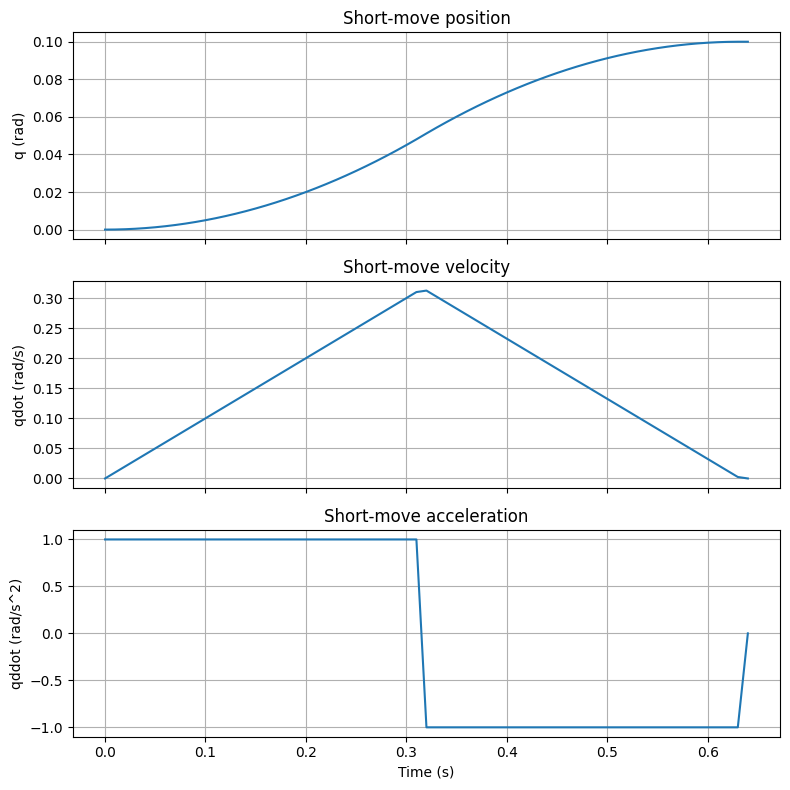

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t_short, q_short)
axes[0].set_ylabel('q (rad)')
axes[0].set_title('Short-move position')
axes[0].grid(True)

axes[1].plot(t_short, qd_short)
axes[1].set_ylabel('qdot (rad/s)')
axes[1].set_title('Short-move velocity')
axes[1].grid(True)

axes[2].plot(t_short, qdd_short)
axes[2].set_ylabel('qddot (rad/s^2)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Short-move acceleration')
axes[2].grid(True)

plt.tight_layout()

**Reading it:** the velocity rises and falls linearly, a **triangle** with no flat segment; the acceleration is +1 then −1
with no zero section between.

**Example: the same robot with a trapezoid (lower velocity limit)**

```python
print(scalar_profile_timing(0.0, 1.0, 0.5, 1.0))
```

Output:
```text
{'dq': 1.0, 'dq_abs': 1.0, 'direction': 1.0, 'ta': 0.5, 'tc': 1.5, 'tf': 2.5, 'vpeak': 0.5, 'profile_type': 'trapezoidal'}
```

With $v_{max} = 0.5$: $v_{max}^2/a_{max} = 0.25$ rad < 1 rad, so there is a cruise: $t_a = 0.5$, $t_c = 1.5$, $t_f = 2.5$ s, the PDF example in SI form.

## Bridge to the Practical Workflow

### 18. Sample the trajectory for position commands

The generated trajectory can be sampled and sent as a sequence of joint-position commands. In the myCobot stack, this corresponds to publishing sampled joint targets to `/mycobot/joint_command` as a `Float64MultiArray` in **radians**. The controller converts to degrees internally before sending to the hardware.

**Note:** The codebase's `_build_ee_profile()` outputs velocity commands per tick rather than position waypoints — the controller integrates velocities into angle targets at 20 Hz. The position-sampled approach below is a simpler notebook-friendly alternative that achieves the same practical result.

In [18]:
# Inspect the first few sampled joint targets
print('First 5 sampled joint commands (rad):')
print(q_traj[:5, :])

First 5 sampled joint commands (rad):
[[ 0.       -0.785398 -0.785398  0.        0.523599  0.      ]
 [ 0.0002   -0.785248 -0.785548  0.0001    0.523699 -0.00015 ]
 [ 0.0008   -0.784798 -0.785998  0.0004    0.523999 -0.0006  ]
 [ 0.0018   -0.784048 -0.786748  0.0009    0.524499 -0.00135 ]
 [ 0.0032   -0.782998 -0.787798  0.0016    0.525199 -0.0024  ]]


**Concept.** Each row of `q_traj` is one joint target at one instant; publishing the rows in order at the sample rate replays
the trajectory. The first steps are tiny (the arm starts from rest).

**Example: how big are the steps between two commands?**

```python
step = np.abs(np.diff(q_traj, axis=0))
print(f'largest change of any joint between two commands: {np.degrees(step.max()):.2f} deg;  {1 / dt:.0f} commands per second')
```

Output:
```text
largest change of any joint between two commands: 1.16 deg;  50 commands per second
```

### 19. Optional ROS 2 bridge to `/mycobot/joint_command`

If the myCobot control stack is running, publish the sampled joint trajectory at a fixed rate. Ensure the controller launch is running in a separate terminal before publishing.

**Important:** `/mycobot/joint_command` expects joint angles in **radians**.

**[MOVES] Real robot.** Before the cell below: `mycobot_control` running on the Pi, the notebook's ROS environment
matching it (same `ROS_DOMAIN_ID`), workspace clear, hand at the power switch.

⚠ **The trajectory starts at `q_start`.** If the arm is somewhere else (the parked pose is about
`[7, −99, −71, 81, 90, −74]°`), the first command would be a **jump** to `q_start`, exactly the step trajectory planning
avoids. So the cell reads the measured pose and refuses if any joint is more than 5° from the first sample. To plan from
where the arm is: in Task 8 set `q_start = <measured pose printed here>` and `q_goal = q_start + np.radians([20, 10, -10,
0, 0, 0])` (a small first move), re-run Tasks 8–15, then this cell.

In [ ]:
import rclpy
from rclpy.node import Node
from std_msgs.msg import Float64MultiArray
from sensor_msgs.msg import JointState                    # added: read the measured pose
from rclpy.wait_for_message import wait_for_message       # added

if not rclpy.ok():
    rclpy.init(args=None)

class TrajectoryCommandNode(Node):
    def __init__(self):
        super().__init__('trajectory_planning_lab_node')
        self.pub = self.create_publisher(Float64MultiArray, '/mycobot/joint_command', 10)

traj_node = TrajectoryCommandNode()

publish_traj = True  # set True only when the controller is running   (real robot: on)

# added safety: the trajectory must start where the arm is (otherwise the first command is a jump)
ok, js = wait_for_message(JointState, traj_node, '/mycobot/joint_states', time_to_wait=3.0)
assert ok, 'no /mycobot/joint_states: is mycobot_control running (same ROS_DOMAIN_ID)?'
gap_deg = np.degrees(np.abs(q_traj[0, :] - np.array(js.position)))
print('measured pose (deg):', np.round(np.degrees(js.position), 1), '  gap to q_traj[0] (deg):', np.round(gap_deg, 1))
assert np.all(gap_deg <= 5), 'the arm is not at q_start: plan from the measured pose (see above), then run this cell again'

if publish_traj:
    for k in range(len(t_sync)):
        msg = Float64MultiArray()
        msg.data = q_traj[k, :].tolist()  # joint targets in radians
        traj_node.pub.publish(msg)
        rclpy.spin_once(traj_node, timeout_sec=0.0)
        time.sleep(dt)

# Optional cleanup:
# traj_node.destroy_node()
# rclpy.shutdown()

**Concept.** Replay: one `Float64MultiArray` (six angles in **radians**) per sample, every `dt` = 20 ms. For each message
`mycobot_control` sends one `send_angles` at its fixed speed 50 and reads the angles back.

**How it works**
- `wait_for_message(Type, node, topic, time_to_wait)` returns `(ok, msg)` for **one** message; `js.position` = six angles (rad).
- `np.abs(q_traj[0, :] - q_measured)` = per-joint gap; the `assert` stops the cell before anything is published.
- `for k in range(len(t_sync)):` one message per row; `time.sleep(dt)` paces the loop. The pacing drifts slightly (the
  loop's own time adds to every step), so the replay takes a little longer than $t_f$.
- **[check] on the robot:** 50 messages per second is faster than the controller's 20 Hz tick, and each message triggers a
  serial read. If the arm stops short of `q_goal`, publish the last row once more, or resample to 20 Hz.

⚠ **What `/mycobot/joint_states` really is** (read in `mycobot_control.py`, `_state_timer`; seen in the simulation,
not yet checked on the robot): the controller publishes its **estimate** of the angles at 5 Hz and reads the robot only
right after a command. After a `/mycobot/joint_command` that read happens immediately, before the arm has moved, so the
published pose stays at the *old* angles until the next command. Two consequences: (1) the "measured" pose you read
can lag one move behind; (2) a **velocity** command sent after a position command first drives the joints back towards
that stale estimate. Refresh the estimate after a position move by publishing the same target again once the arm has
stopped (no motion, but a new read). (3) Ending a velocity command with zeros makes the controller send **STOP** to the
robot, and the position path (`_pos_cb`) never sends **RESUME**; if the robot ignores motion after STOP (as the Lab 7
template says, and the simulation does), every later `/mycobot/joint_command` is ignored until a new velocity command
makes the controller resume. Wake-up: publish one small velocity message (e.g. 0.02 rad/s on one joint), then the position
command. **[check] on the robot.**

> ### 🧪 Simulation (optional, only without the robot)
> The code cell above is the real-robot version. To run it **without** the robot:
> 1. Terminal 1 (laptop): `python3 solutions/sim_robot.py --start-deg 0 -45 -45 0 30 0` (starts at `q_start`) → it prints the virtual port, e.g. `/dev/pts/5`.
> 2. Terminal 2: start the **real** controller node on that port, isolated from the lab network:
>    ```bash
>    source /opt/ros/jazzy/setup.bash && source ros2_ws/install/setup.bash
>    export ROS_DOMAIN_ID=99 ROS_AUTOMATIC_DISCOVERY_RANGE=LOCALHOST
>    ros2 run mycobot_control mycobot_control --ros-args -p port:=/dev/pts/5 -p read_timeout_s:=0.75
>    ```
> 3. Notebook: restart the kernel, run the cells from the top up to (not including) the ROS cell, run the cell below,
>    then the ROS cell(s) above. Terminal 1 prints every command the simulated arm receives.
>
> ⚠ The isolation (`ROS_DOMAIN_ID=99`, localhost only) is what keeps a simulation from commanding the real arm: with the
> lab's domain id, the same `/mycobot/...` messages would also reach the real controller on the Pi. It must be set
> **before** `rclpy.init()`, hence the kernel restart.

In [ ]:
# SIMULATION ONLY: run before rclpy.init() (after a kernel restart), never in the lab with the real robot
import os
os.environ['ROS_DOMAIN_ID'] = '99'                           # not the lab's domain id
os.environ['ROS_AUTOMATIC_DISCOVERY_RANGE'] = 'LOCALHOST'    # talk only to nodes on this computer

---
## Short questions from the PDF (quiz and interview preparation)
1. **Objective of trajectory planning?** Turn start, goal and limits into a time-parameterised reference $q(t), \dot q(t),
   \ddot q(t)$ the robot can execute: smooth, within the limits, starting and ending at rest.
2. **Path vs trajectory?** A path is the geometric curve (configurations, no time); a trajectory is a path plus a timing law.
3. **True statements:** a) true (limits are the planner's input); b) **false** for the trapezoid: the acceleration jumps
   between $+a_{max}$, 0, $-a_{max}$ (S-curves or higher-order polynomials make it continuous); c) **false**: this planning
   is *kinematic*, it needs only limits, no dynamic model; d) true (position and velocity must be continuous).
4. **Sketch:** velocity = trapezoid; position = S-curve (parabola, line, parabola); acceleration = $+a_{max}$, 0, $-a_{max}$ (Task 7).
5. **When triangular?** If $|\Delta q| \le v_{max}^2/a_{max}$.
6. **Three phases:** accelerate (velocity rises linearly, position quadratic), cruise (constant velocity, position linear),
   decelerate (mirror of the first).
7. **Influence on time:** trapezoid $t_f = v_{max}/a_{max} + |\Delta q|/v_{max}$; triangle $t_f = 2\sqrt{|\Delta q|/a_{max}}$,
   independent of $v_{max}$ (the myCobot case, Task 9).
8. **Why smooth profiles, not steps?** A step needs infinite acceleration: servos saturate, mechanics vibrate, tracking errors
   and overshoot grow, the robot can jump. Smooth profiles stay within the limits and are predictable.

## Summary
- Trapezoid if $|\Delta q| > v_{max}^2/a_{max}$, else triangle; $t_f = 2t_a + t_c$ or $2\sqrt{|\Delta q|/a_{max}}$.
- Multi-joint: one dominant joint, the others scaled by $r_j = \Delta q_j/\Delta q_{dom}$: same timing, limits kept.
- With the controller's limits (150°/s, 1 rad/s²) every joint move is triangular: the **acceleration** limit sets the time.
- Guard the `np.arange` overshoot; on the robot, plan **from the measured pose**.